In [4]:
!pip install causalgraphicalmodels



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [8]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Note: you may need to restart the kernel to use updated packages.


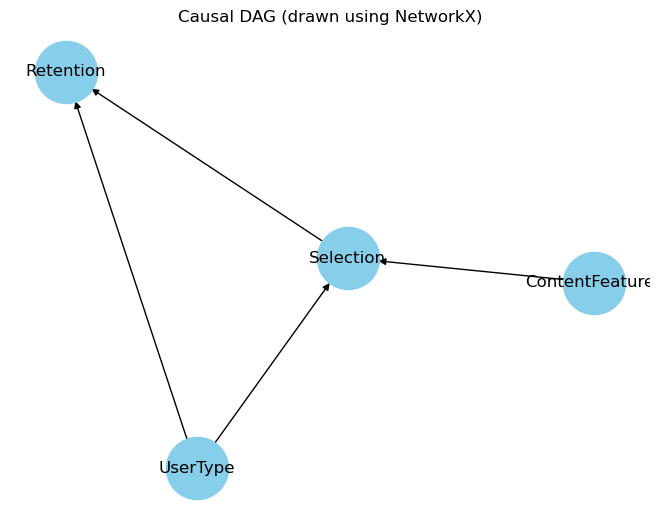

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
edges = [
    ("ContentFeatures", "Selection"),
    ("UserType", "Selection"),
    ("UserType", "Retention"),
    ("Selection", "Retention")
]
G.add_edges_from(edges)

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, arrows=True)
plt.title("Causal DAG (drawn using NetworkX)")
plt.show()


### 📌 Backdoor Adjustment Explanation

To estimate the causal effect of content features (such as genre, rating, etc.) on user retention, we must consider that user type is a confounder — it affects both selection and retention.

Using Judea Pearl’s backdoor criterion:

> `do(Retention | do(ContentFeature)) ≈ E[Retention | ContentFeature, UserType]`

This means we can approximate the causal effect of content by conditioning on user type — even without running a live A/B test — if we can proxy user segmentation through behavioral modeling.


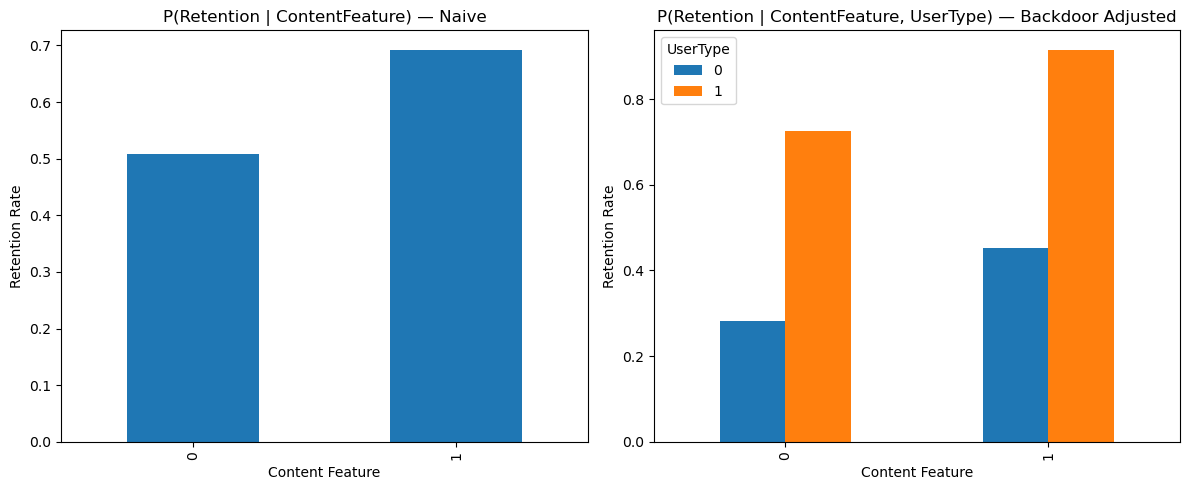

In [23]:
import pandas as pd
import numpy as np

# Step 1: Create a synthetic dataset of 1000 samples
np.random.seed(42)
n_samples = 1000

# Simulate content feature: 1 = high attention-grabbing (e.g. flashy genre), 0 = standard
content_feature = np.random.binomial(1, 0.5, size=n_samples)

# Simulate user type (latent): 0 = passive, 1 = active
user_type = np.random.binomial(1, 0.5, size=n_samples)

# Selection probability depends on both content_feature and user_type
selection_prob = 0.3 + 0.4 * content_feature + 0.3 * user_type
selection = np.random.binomial(1, selection_prob.clip(0, 1))

# Retention probability: depends on user_type and whether user selected the content
retention_prob = 0.2 + 0.3 * user_type + 0.4 * selection
retention = np.random.binomial(1, retention_prob.clip(0, 1))

# Combine into a DataFrame
df_sim = pd.DataFrame({
    'ContentFeature': content_feature,
    'UserType': user_type,
    'Selection': selection,
    'Retention': retention
})

# Naive estimation: P(Retention | ContentFeature)
p_ret_given_cf = df_sim.groupby('ContentFeature')['Retention'].mean()

# Backdoor adjusted estimation: P(Retention | ContentFeature, UserType)
p_ret_given_cf_ut = df_sim.groupby(['ContentFeature', 'UserType'])['Retention'].mean().unstack()

import matplotlib.pyplot as plt

# Plot both
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Naive
p_ret_given_cf.plot(kind='bar', ax=ax[0])
ax[0].set_title("P(Retention | ContentFeature) — Naive")
ax[0].set_xlabel("Content Feature")
ax[0].set_ylabel("Retention Rate")

# Backdoor adjusted
p_ret_given_cf_ut.plot(kind='bar', ax=ax[1])
ax[1].set_title("P(Retention | ContentFeature, UserType) — Backdoor Adjusted")
ax[1].set_xlabel("Content Feature")
ax[1].set_ylabel("Retention Rate")

plt.tight_layout()
plt.show()


### 🎯 Why Causality Matters

The naive observational estimate `P(Retention | ContentFeature)` suggests that high-attention content drives retention. However, this overlooks confounding from `UserType`.

After adjusting for `UserType`, we see that:
- Active users retain more regardless of content.
- ContentFeature does impact retention — but the true effect is only visible when confounding is accounted for.

This illustrates why **causal inference** is essential in product decisions. Without it, we might overestimate the value of a specific content type, when in fact, user behavior is driving the observed pattern.
